In [3]:
"""
Three-panel TR summary figure: trapped Poincare map, Delta_res profile, and the
Omega_eta profile -- all against rho = sqrt(s).

  (a) firm3d trapped map, eta vs rho, in firm3d's own plotting convention.
  (b) Delta_res(rho) = sum_{p,q} Delta_s(rho, p, q)**4 * w(rho, p, q),
      where w is the objective's `res_weight`. Plotted for both weighting
      methods: f_L = weight_method "linear", f_b = weight_method "bump".
  (c) Omega_eta(rho) from the objective, with the dominant rationals marked.

Note the y coordinate is rho, not s: the Poincare data is stored in s, so it is
converted with rho = sqrt(s). The objective's own radial grid is already rho
(`rhos`), with s_prof = rhos**2.

Usage:
    python plot_tr_three_panel.py --Efrac 1e-3
"""

import argparse
from math import gcd
from pathlib import Path

import matplotlib
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

In [4]:
from matplotlib import font_manager
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 4

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)

plt.rcParams.update(
    {
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.14, right=0.98, bottom=0.14, top=0.82) # percentages of the figure height/width

# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)


In [5]:
from types import SimpleNamespace

# Notebook defaults (mirrors plot_tr_three_panel.py argparse)
Efrac = "1e-4"
tr_dir = "../data_tr"
poinc_dir = "../data"
out_dir = "../forpaper"
tag = "precise_QA_Bcrit_0.98"
poinc_suffix = "_ns600"
tr_suffix = "_hires"
n_rational = 3
markersize = 0.25
dpi = 300
rho_lim = (0.35, 0.55)  # e.g. (0.2, 1.0), or None
crop = False
exclude = ""            # e.g. "2/1,1/3"
exclude_margin = 0.005
keep_excluded_in_sum = False
log_dres = False
suffix = ""

# Keep `args.*` working in the plotting cells below
args = SimpleNamespace(
    Efrac=Efrac,
    tr_dir=tr_dir,
    poinc_dir=poinc_dir,
    out_dir=out_dir,
    tag=tag,
    poinc_suffix=poinc_suffix,
    tr_suffix=tr_suffix,
    n_rational=n_rational,
    markersize=markersize,
    dpi=dpi,
    rho_lim=rho_lim,
    crop=crop,
    exclude=exclude,
    exclude_margin=exclude_margin,
    keep_excluded_in_sum=keep_excluded_in_sum,
    log_dres=log_dres,
    suffix=suffix,
)

In [6]:
out_dir = Path(args.out_dir)
out_dir.mkdir(parents=True, exist_ok=True)
efrac = float(args.Efrac)

In [7]:
def delta_res(path, drop=()):
    """Delta_res(rho) = sum over (p, q) of Delta_s**4 * res_weight.

    `drop` holds reduced fractions to omit from the sum. This matters for the
    bump weighting: its support is much wider than Delta_s, so a resonance still
    contributes well outside its own island -- at 1e-4 the excluded 1/3 chain
    supplies 99.9% of f_b at rho = 0.808, which is inside a window chosen to
    exclude it. Linear weighting touches only the two bracketing surfaces, so
    there f_L is exactly zero and the radial cut alone suffices.
    """
    d = np.load(path, allow_pickle=True)
    v = d["val"][()]
    Dp = np.asarray(v["Delta_s_prof"])[:, 0, 0, :]  # (rho, res)
    w = np.asarray(v["res_weight"])[:, 0, 0, :]  # (rho, res)
    Dp = np.where(np.isfinite(Dp), Dp, 0.0)
    w = np.where(np.isfinite(w), w, 0.0)
    contrib = Dp**4 * w
    if drop:
        pa, qa = v["p_arr"].astype(int), v["q_arr"].astype(int)
        mask = np.ones(contrib.shape[-1], dtype=bool)
        for j in range(contrib.shape[-1]):
            g = gcd(abs(int(pa[j])), abs(int(qa[j]))) or 1
            if (int(pa[j]) // g, int(qa[j]) // g) in drop:
                mask[j] = False  # drops every harmonic of that rational
        contrib = contrib[:, mask]
    return contrib.sum(axis=-1), v


In [8]:
drop = set()
if args.exclude.strip() and not args.keep_excluded_in_sum:
    drop = {
        tuple(int(x) for x in t.strip().split("/"))
        for t in args.exclude.split(",")
        if t.strip()
    }

f_lin = Path(args.tr_dir) / f"tr_{args.tag}_Efrac_{args.Efrac}{args.tr_suffix}.npz"
f_bmp = Path(args.tr_dir) / f"tr_{args.tag}_Efrac_{args.Efrac}{args.tr_suffix}_bump.npz"

dres_L, val = delta_res(f_lin, drop)
dres_b, _ = delta_res(f_bmp, drop)

rhos = np.asarray(val["rhos"]).ravel()
Omega = np.asarray(val["Omega"])[:, 0, 0]
good = Omega < 11  # 11 is the objective's fill_value ("no well found")

print(f"E/E_alpha = {args.Efrac}")
if drop:
    print("dropped from Delta_res sum (all harmonics): "
          + ", ".join(f"{p}/{q}" for p, q in sorted(drop)))
print(f"rho grid  : {rhos.size} points, {rhos.min():.4f} -> {rhos.max():.4f}")
print(f"Omega_eta : [{Omega[good].min():.4f}, {Omega[good].max():.4f}]")
print(f"Delta_res : max f_L {dres_L.max():.3e}  at rho {rhos[dres_L.argmax()]:.3f}")
print(f"            max f_b {dres_b.max():.3e}  at rho {rhos[dres_b.argmax()]:.3f}")

# dominant rationals, collapsed onto reduced fractions
ok = np.isfinite(val["Delta_s"][0, 0, :])
D_, s_, p_, q_ = (
    val["Delta_s"][0, 0, ok],
    val["s_res"][0, 0, ok],
    val["p_arr"][ok].astype(int),
    val["q_arr"][ok].astype(int),
)

m = (D_ > 0) & (s_ > 0)
best = {}
for D, sr, p, q in zip(D_[m], s_[m], p_[m], q_[m]):
    g = gcd(abs(int(p)), abs(int(q))) or 1
    k = (int(p) // g, int(q) // g)
    if k not in best or D > best[k][0]:
        best[k] = (D, sr)
top = sorted(((D, sr, p, q) for (p, q), (D, sr) in best.items()), key=lambda t: -t[0])
top = top[: args.n_rational]
print("dominant rationals: " + ", ".join(f"{p}/{q} at rho={np.sqrt(sr):.3f}"
                                          for _D, sr, p, q in top))
D, sr, p, q = top[1]
top[1] = (D, sr, 2, 2)

E/E_alpha = 1e-4
rho grid  : 120 points, 0.0083 -> 1.0000
Omega_eta : [0.2617, 2.8006]
Delta_res : max f_L 1.232e-06  at rho 0.833
            max f_b 1.757e-07  at rho 0.867
dominant rationals: 1/3 at rho=0.830, 1/1 at rho=0.399, 2/3 at rho=0.514


map       : 9490 trajectories with >=1 return
map rho extent : 0.2130 -> 0.9148
plotted window : 0.3500 -> 0.5500
widest chains inside the window: 1/1 (rho=0.399, Ds=0.01536), 2/3 (rho=0.514, Ds=0.01171), 3/4 (rho=0.476, Ds=0.00803), 4/5 (rho=0.457, Ds=0.00616), 5/6 (rho=0.446, Ds=0.00427), 5/7 (rho=0.491, Ds=0.00361), 6/7 (rho=0.438, Ds=0.00279), 7/8 (rho=0.433, Ds=0.00278)
plotted     : 726 trajectories (stride=3) overlapping rho=[0.350,0.550]  (2163521 points)


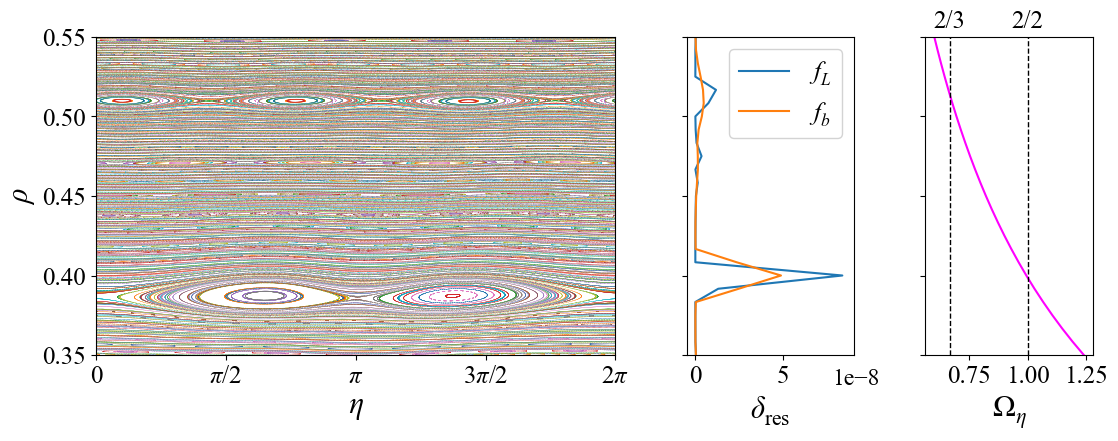

In [9]:
# --- Poincare map ------------------------------------------------------
pc = np.load(
    Path(args.poinc_dir) / f"{args.tag}_poincare_data_Efrac_{efrac:.1e}{args.poinc_suffix}.npz",
    allow_pickle=True,
)
s_all, etas_all, nret = pc["s_all"], pc["etas_all"], pc["nreturns"]
alive = np.where(nret >= 1)[0]
print(f"map       : {len(alive)} trajectories with >=1 return")

# Map extent (cheap: one min/max per trajectory, no plotting)
rho_lo_map = min(
    (np.sqrt(np.asarray(s_all[i], float).min()) for i in alive), default=0.0
)
rho_hi_map = max(
    (np.sqrt(np.asarray(s_all[i], float).max()) for i in alive), default=1.0
)

# Resolve rho window BEFORE plotting so we can skip out-of-window points
if args.rho_lim is not None:
    rlo, rhi = args.rho_lim
elif args.exclude.strip():
    # Cut the confined region at every excluded chain's island edges and keep the
    # widest surviving band. Widths come from the same rho-weighted Delta_s that
    # panel (b) is built from, so the window is defined by the prediction itself.
    want = [t.strip() for t in args.exclude.split(",") if t.strip()]
    bands = []
    for lbl in want:
        pq = tuple(int(x) for x in lbl.split("/"))
        if pq not in best:
            print(f"!! {lbl} not among the predicted resonances, ignoring")
            continue
        D, sr = best[pq]
        lo_s, hi_s = max(sr - 0.5 * D, 0.0), sr + 0.5 * D
        b = (
            np.sqrt(lo_s) - args.exclude_margin,
            np.sqrt(hi_s) + args.exclude_margin,
        )
        bands.append(b)
        print(f"excluding {lbl:5s} rho in [{b[0]:.4f}, {b[1]:.4f}]  "
              f"(s_res={sr:.4f}, Delta_s={D:.5f})")
    edges = [rho_lo_map] + [x for b in sorted(bands) for x in b] + [rho_hi_map]
    gaps = [
        (edges[i], edges[i + 1])
        for i in range(0, len(edges) - 1)
        if edges[i + 1] > edges[i]
        and not any(edges[i] < b[1] and edges[i + 1] > b[0] for b in bands)
    ]
    if gaps:
        rlo, rhi = max(gaps, key=lambda g: g[1] - g[0])
    else:
        print("!! no gap survives the exclusions; falling back to the crop")
        pad = 0.03 * (rho_hi_map - rho_lo_map)
        rlo, rhi = max(0.0, rho_lo_map - pad), min(1.0, rho_hi_map + pad)
elif args.crop:
    pad = 0.03 * (rho_hi_map - rho_lo_map)
    rlo, rhi = max(0.0, rho_lo_map - pad), min(1.0, rho_hi_map + pad)
else:
    rlo, rhi = 0.0, 1.0

print(f"map rho extent : {rho_lo_map:.4f} -> {rho_hi_map:.4f}")
print(f"plotted window : {rlo:.4f} -> {rhi:.4f}")
kept = sorted(
    ((np.sqrt(sr), f"{p}/{q}", D) for (p, q), (D, sr) in best.items()
     if rlo <= np.sqrt(sr) <= rhi and D > 0),
    key=lambda t: -t[2],
)[:8]
print("widest chains inside the window: "
      + ", ".join(f"{lbl} (rho={r:.3f}, Ds={D:.5f})" for r, lbl, D in kept))

# --- figure ------------------------------------------------------------
fig, (ax0, ax1, ax2) = plt.subplots(
    1, 3, figsize=(11.2, 4.3), gridspec_kw={"width_ratios": [3.1, 1, 1]},
    sharey=True,
)

# Per-trajectory scatter with the default color cycle. Color advances only when
# a trajectory is actually drawn (rho-window hits); stride skips never touch it.
traj_stride = 3
s_lo, s_hi = rlo * rlo, rhi * rhi
n_traj_used = 0
n_pts = 0
for i in alive[::traj_stride]:
    s = np.asarray(s_all[i], float)
    e = np.asarray(etas_all[i], float)
    n = min(s.size, e.size)
    s, e = s[:n], e[:n]
    if s.size == 0 or s.max() < s_lo or s.min() > s_hi:
        continue
    m = (s >= s_lo) & (s <= s_hi)
    if not np.any(m):
        continue
    ax0.scatter(
        np.mod(e[m], 2 * np.pi), np.sqrt(s[m]),
        marker="o", s=0.05, edgecolors="none", rasterized=True,
    )
    n_traj_used += 1
    n_pts += int(m.sum())
print(f"plotted     : {n_traj_used} trajectories (stride={traj_stride}) "
      f"overlapping rho=[{rlo:.3f},{rhi:.3f}]  ({n_pts:d} points)")

ax0.set_xlim([0, 2 * np.pi])
ax0.set_ylim([rlo, rhi])
ax0.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax0.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax0.set_xlabel(r"$\eta$", **label_kw)
ax0.set_ylabel(r"$\rho$", **label_kw)

# Panels (b)/(c): only the requested rho window
vis = (rhos >= rlo) & (rhos <= rhi)
ax1.plot(dres_L[vis], rhos[vis], label=r"$f_L$")
ax1.plot(dres_b[vis], rhos[vis], label=r"$f_b$")
ax1.set_xlabel(r"$\delta_{\rm res}$", **label_kw)
ax1.legend(loc="best", frameon=True, framealpha=0.85, fontsize=tick_labelsize)

if vis.any():
    dmax = max(dres_L[vis].max(), dres_b[vis].max())
    if args.log_dres:
        pos = np.concatenate([dres_L[vis], dres_b[vis]])
        pos = pos[pos > 0]
        ax1.set_xscale("log")
        if pos.size:
            ax1.set_xlim(max(pos.min() * 0.5, dmax * 1e-5), dmax * 2)
    else:
        ax1.set_xlim(-0.5 * 10**(-8), dmax * 1.08 if dmax > 0 else 1)
elif not args.log_dres:
    ax1.set_xlim(left=0)

vis_o = vis & good
ax2.plot(Omega[vis_o], rhos[vis_o], color="magenta")
if vis_o.any():
    olo, ohi = Omega[vis_o].min(), Omega[vis_o].max()
    pad_o = 0.06 * (ohi - olo) if ohi > olo else 0.1
    ax2.set_xlim(olo - pad_o, ohi + pad_o)
xlo, xhi = ax2.get_xlim()
for _D, sr, p, q in top:
    if not (xlo <= p / q <= xhi):
        continue  # rational lies outside the plotted Omega window
    ax2.axvline(p / q, color="k", ls="--", lw=1)
    ax2.text(
        p / q, 1.01, f"{p}/{q}", rotation=0, fontsize=tick_labelsize, ha="center",
        va="bottom", transform=ax2.get_xaxis_transform(),
    )
ax2.set_xlim(xlo, xhi)
ax2.set_xlabel(r"$\Omega_\eta$", **label_kw)

# # Mark the outermost confined orbit if it falls inside the window
# if rho_hi_map < 0.99 and rlo < rho_hi_map < rhi:
#     for a in (ax0, ax1, ax2):
#         a.axhline(rho_hi_map, color="0.35", ls=":", lw=1.0)
#     ax1.text(
#         0.97, rho_hi_map + 0.008 * (rhi - rlo), "outermost confined orbit",
#         fontsize=6.5, color="0.35", ha="right", va="bottom",
#         transform=ax1.get_yaxis_transform(),
#     )
# print(f"outermost confined rho = {rho_hi_map:.4f}")

ax0.tick_params('both', labelsize=tick_labelsize)
ax1.tick_params('both', labelsize=tick_labelsize)
ax2.tick_params('both', labelsize=tick_labelsize)

AXES_MARGINS = dict(left=0.09, right=0.98, bottom=0.18, top=0.92) # percentages of the figure height/width
apply_standard_axes(fig)

# fig.tight_layout()
out = out_dir / f"{args.tag}_TR_three_panel_Efrac_{args.Efrac}{args.suffix}.png"
# Don't retarget offsetText's transform: XAxis stores its y in display
# pixels, so transAxes would read that as an axes fraction and explode the
# figure bbox. Hide it and place a normal axes-fraction Text instead.
fig.canvas.draw()
off = ax1.xaxis.get_offset_text()
off_txt = off.get_text()
off.set_visible(False)
if off_txt:
    ax1.text(
        0.87, -0.04, off_txt,
        transform=ax1.transAxes,
        fontsize=tick_labelsize-1,
        ha="left",
        va="top",
        clip_on=False,
    )
fig.savefig(out, dpi=args.dpi)
fig.savefig(out.with_suffix(".pdf"))
# print(f"\nwrote {out.name}")
# plt.show()
